# CEBRA-Lens Demo

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AdaptiveMotorControlLab/CEBRA-lens/blob/main/Notebooks/Demo-Notebook-Allen.ipynb)

<!-- #fix the link later -->

### Download dataset

This notebook will demo how to use CEBRA-Lens on the Allen visual dataset. To download the allen data please follow the [link](https://figshare.com/s/60adb075234c2cc51fa3?file=36869049). Make sure the data is placed in a folder `/data`. As a prerequisite for the notebook you should have models already trained. If not, you can refer to the [Generate Models notebook](ModelGenerator.ipynb).

In [1]:
import CEBRA_lens.cebra_lens as lens

c:\Users\Eloise\miniconda3\envs\cebra_lens\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


### Load data and models

Data is loaded here with a utils functions for the Allen dataset. Models are loaded by using the name of the folder where they are located as well as the folder path. It will load all the models ending with .pt located in the path, thus these models should be saved as **torch** and not as sklearn. This was done due to easier loading on the CPU compared to the sklearn

The function model_loader allows for inputing labels for models which allow for grouping based on prefered parameters. The labels are given as a dictionary where the keys correspond to the model file name and the value to the prefered label for that model.

In [2]:
model_path = "FinalModels/VISION/offset10"

Example of labels dictionary:

In [3]:
labels = {'allen_single_session_mouse4_0k_UT_torch':'single_UT',
          'allen_multi_session_10k_3_torch':'multi_TR',
          'allen_multi_session_10k_2_torch':'multi_TR',
          'allen_single_session_mouse4_10k_0_torch':'single_TR',
          'allen_single_session_mouse4_10k_1_torch':'single_TR',
          'allen_multi_session_10k_4_torch':'multi_TR',
          'allen_multi_session_10k_0_torch':'multi_TR',
          'allen_multi_session_10k_1_torch':'multi_TR',
          'allen_single_session_mouse4_10k_3_torch':'single_TR',
          'allen_single_session_mouse4_10k_2_torch':'single_TR',
          'allen_multi_session_0k_UT_torch':'multi_UT',
          'allen_single_session_mouse4_10k_4_torch':'single_TR'}

In [4]:
models = lens.model_loader(model_path, labels=labels)

Model allen_multi_session_0k_UT_torch loaded successfully.
Model allen_multi_session_10k_0_torch loaded successfully.
Model allen_multi_session_10k_1_torch loaded successfully.
Model allen_multi_session_10k_2_torch loaded successfully.
Model allen_multi_session_10k_3_torch loaded successfully.
Model allen_multi_session_10k_4_torch loaded successfully.
Model allen_single_session_mouse4_0k_UT_torch loaded successfully.
Model allen_single_session_mouse4_10k_0_torch loaded successfully.
Model allen_single_session_mouse4_10k_1_torch loaded successfully.
Model allen_single_session_mouse4_10k_2_torch loaded successfully.
Model allen_single_session_mouse4_10k_3_torch loaded successfully.
Model allen_single_session_mouse4_10k_4_torch loaded successfully.


To load data make sure you are in the directory where the `/data` folder is located

In [5]:
session_id = 3
train_datas, valid_datas, discrete_labels_train, discrete_labels_val = (
    lens.utils_allen.get_single_session_datasets()
)
#this works fine
train_data = train_datas[session_id].neural
test_data = valid_datas[session_id].neural
train_label = discrete_labels_train[session_id]
test_label = discrete_labels_val[session_id]

c:\Users\Eloise\miniconda3\envs\cebra_lens\Lib\site-packages\cebra\datasets\allen\single_session_ca.py:246: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  frame_feature = tor

### Model decoding

To verify the model performance the decode_models function can be called. This will give a dictionnary with each key being the name of the model "single_UT" "multi_TR" ... and plot the performance accordingly. This is flexible and can thus take many different models.

In [6]:
from tqdm import tqdm
import torch.nn as nn

In [7]:
dataset_label = "visual"
layer_type = nn.Conv1d
session_id = 3

In [8]:
decoding_models = lens.Decoding(train_data, train_label, test_data, test_label, session_id, dataset_label,layer_type)

In [9]:
results_dict = lens.compute_metric(models, decoding_models, output_only = True)

Processing single_TR: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]


In [ ]:
fig = lens.plot_metric(results_dict, decoding_models)

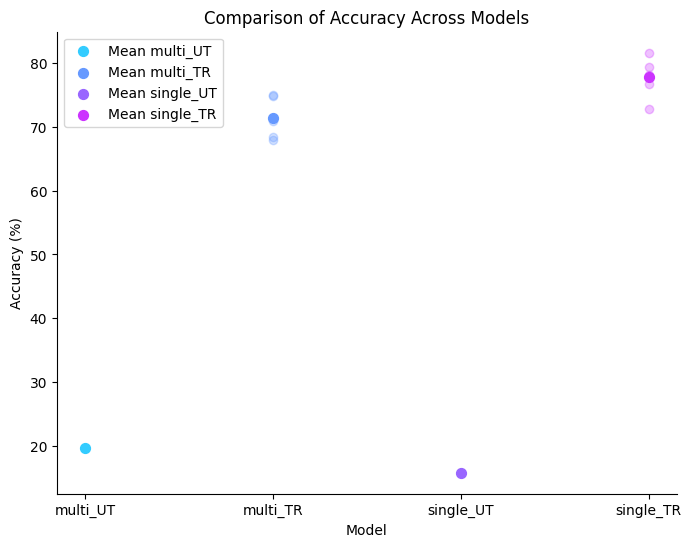

In [ ]:
fig = decoding_models.plot(results_dict=results_dict, palette="cool")

### Model decoding by layer

In [11]:
decode_per_layer =lens.Decoding(train_data, train_label, test_data, test_label, session_id, dataset_label,layer_type)
results_dict = lens.compute_metric(models, decode_per_layer, output_only = False)

Processing single_TR: 100%|██████████| 5/5 [00:27<00:00,  5.43s/it]


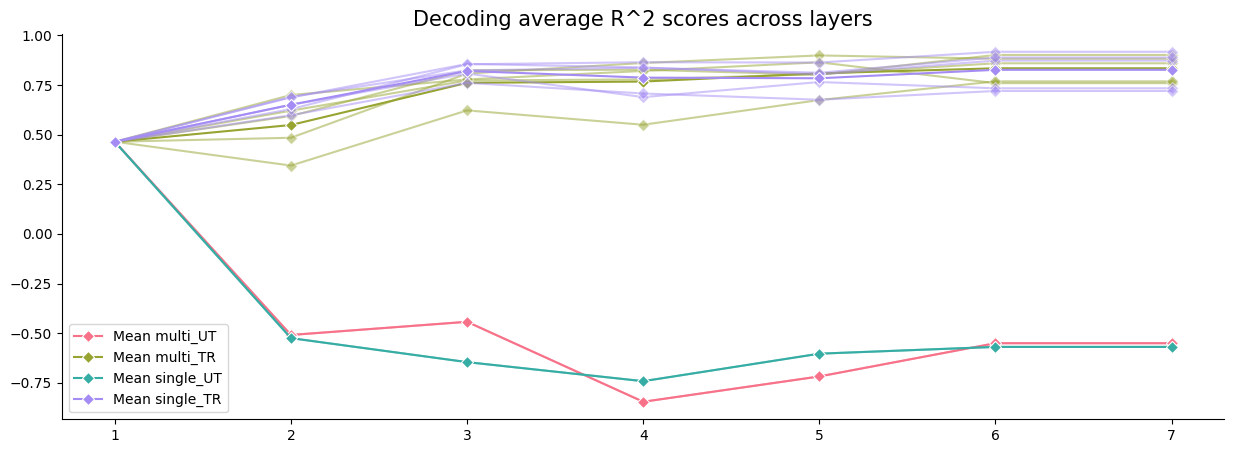

In [12]:
fig = decode_per_layer.plot(results_dict=results_dict)

### Retrieve and compare embeddings

In [8]:
activations_dict = lens.get_activations(
    models=models,
    data=train_data,
    session_id=session_id,
    layer_type=layer_type,
)

#### Plot activations for one model

In [9]:
instance = 0
label = "multi_TR"

In [63]:
plot_data = activations_dict[label][instance]

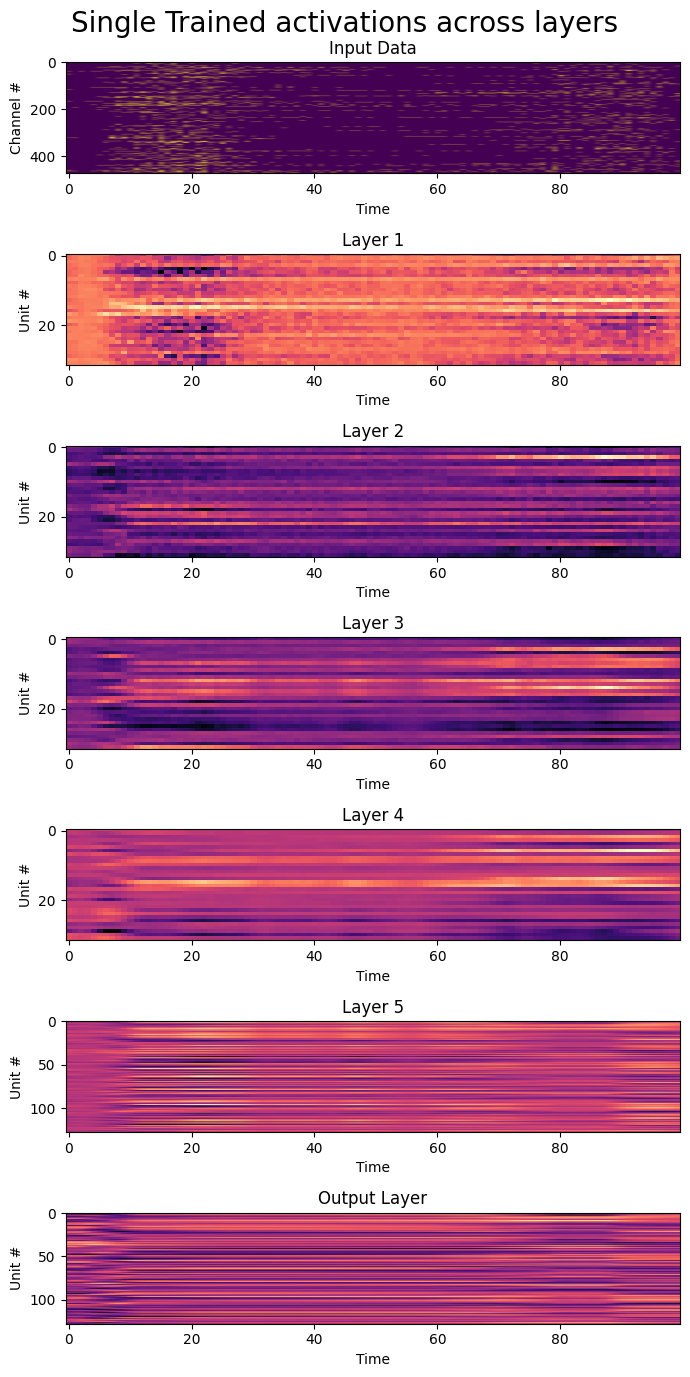

In [16]:
fig = lens.plot_activations(
    train_data,
    plot_data,
    title="Single Trained activations across layers",
    figsize=(7, 14),
)

#### Compare embedddings of two models across layers

In [10]:
model1 = activations_dict["single_TR"][0]
model2 = activations_dict["multi_TR"][0]

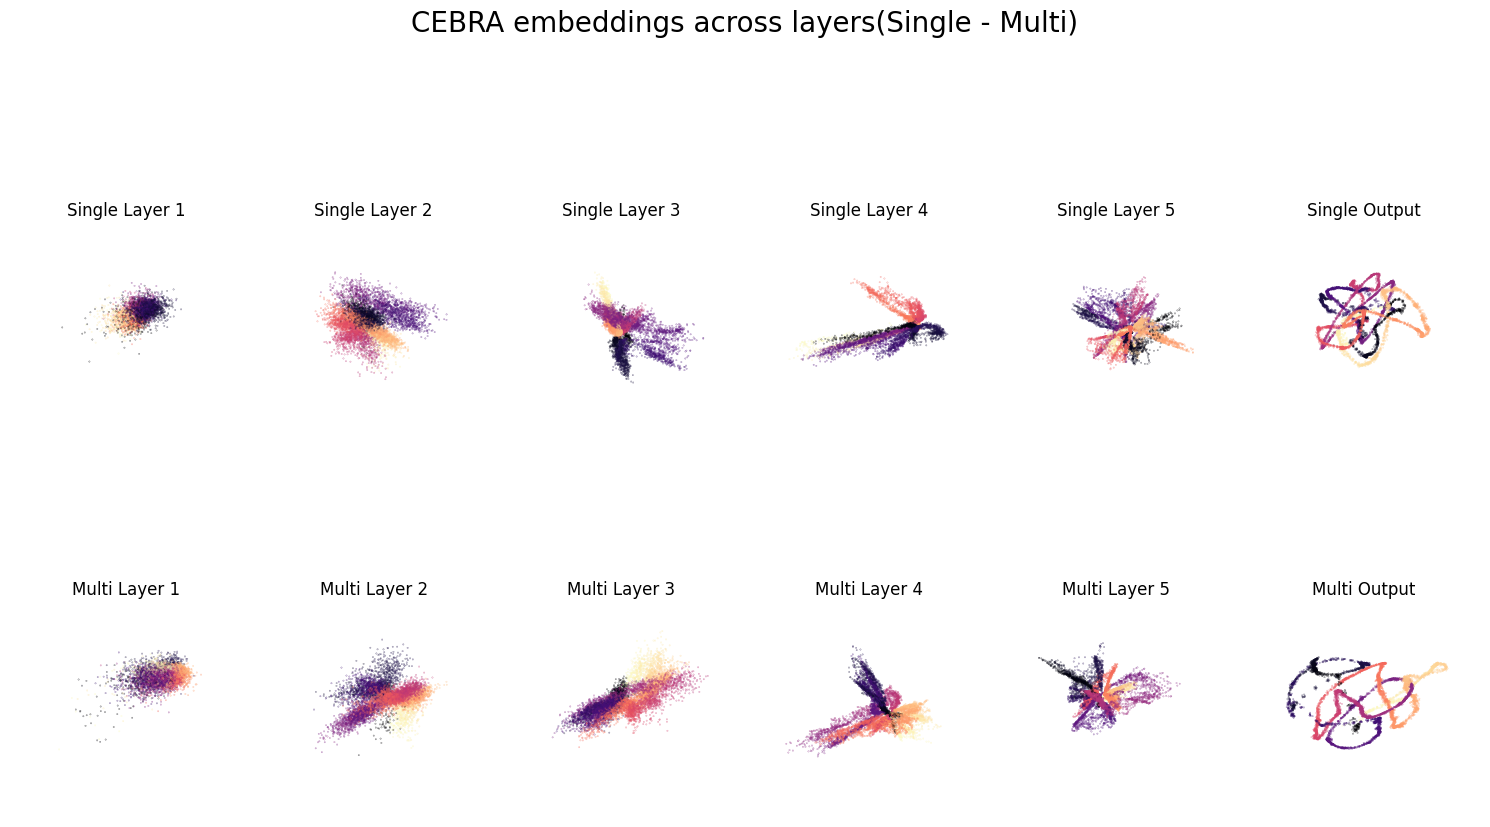

In [ ]:
fig = lens.compare_embeddings_layers(
    model1,
    model2,
    labels=train_label,
    dataset_label=dataset_label,
    sample_plot=model2[0].shape[1],
    comparison_labels=("CEBRA embeddings", ["Single", "Multi"]))

#### Compare embeddings after tSNE dimensionality reduction 

In [30]:
num_samples_tSNE = 2000

In [31]:
tsne_model = lens.Tsne(num_samples_tSNE)
tSNE_dict = lens.compute_metric(activations_dict, tsne_model)

Processing single_TR: 100%|██████████| 5/5 [05:13<00:00, 62.68s/it]


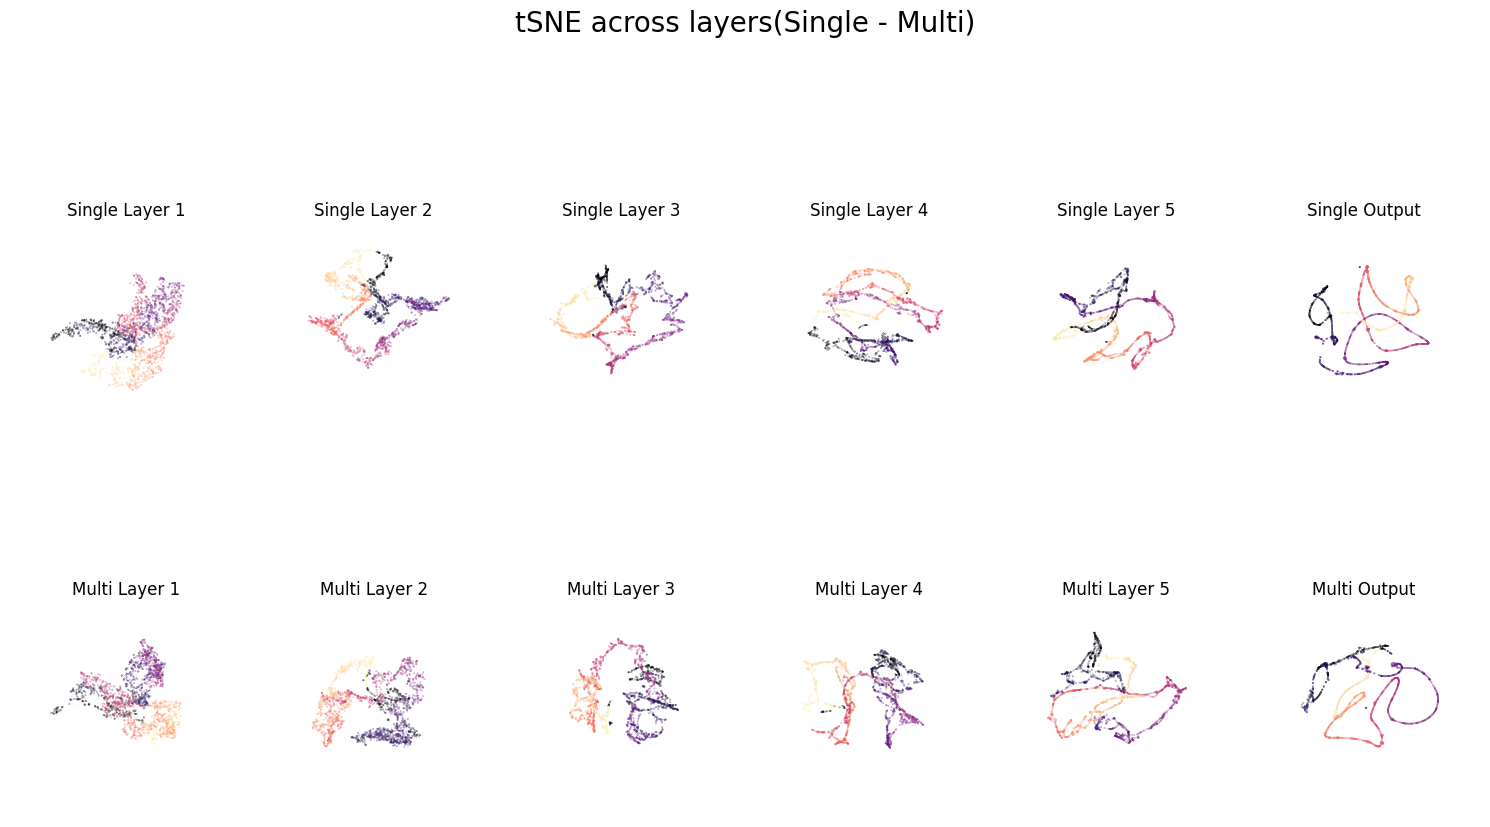

In [39]:
fig = lens.compare_embeddings_layers(
    tSNE_dict["single_TR"][0],
    tSNE_dict["multi_TR"][0],
    labels=train_label,
    dataset_label=dataset_label,
    sample_plot=num_samples_tSNE,
    comparison_labels=("tSNE", ["Single", "Multi"]),
)

### CKA Analysis

To compute the CKA you can chose the desired comparisons and it will create the CKA matrix accordingly. These comparisons are a list of tuples. Where the tuples comprise of model labels

In [12]:
comparisons = [
        ("single_UT", "single_TR"),
        ("multi_UT", "multi_TR"),
        ("single_TR", "multi_TR"),
        ("single_TR", "single_TR"),
        ("multi_TR", "multi_TR"),
    ]

In [13]:
#this is what we want!
cka_multi = lens.CKA(comparisons)
cka_matrices = lens.compute_metric(activations_dict, cka_multi)

100%|██████████| 5/5 [21:38:41<00:00, 15584.32s/it]  


In [ ]:
fig = lens.plot_metric(cka_matrices,cka_multi,annot=False)

In [ ]:
fig = cka_multi.plot(cka_matrices,annot=False)

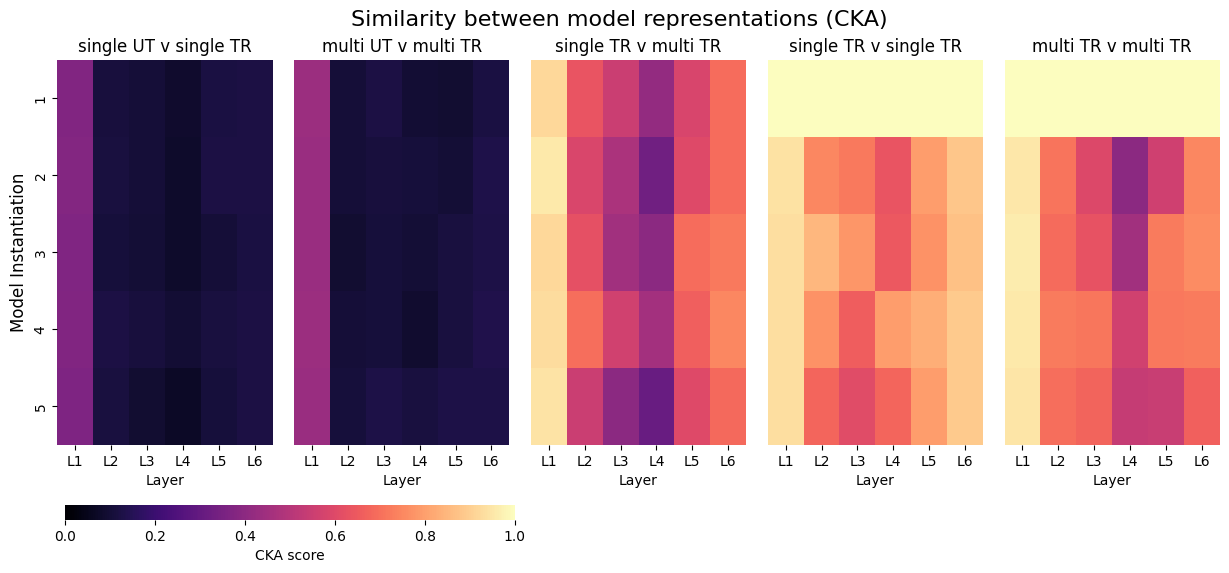

In [42]:
fig = lens.plot_cka_heatmaps(
    cka_matrices=cka_matrices,
    annot=False,
)

### RDM (Representational Dissimilarity Matrix) Analysis

RDM Matrices are huge to save (20Go) but not so long to compute. Be careful when saving it, comment if needed or at least delete it when no longer needed it. rdm_dict will have the same format as activation_dict. It computes the RDM for the whole activation dataset, but smaller datasets can be inputted. It also has the possibility to correlate it to Oracle RDM.

First, we show an example of an RDM computed on all layers of a model instance. We can plot the desired layers.

In [10]:
rdm_single = lens.RDM(
    data=train_data,
    label=train_label,
    dataset_label="visual",
    metric="correlation",
    bool_oracle=False,
)
multi_rdm_corr = rdm_single.compute(activations_dict["multi_TR"][0])

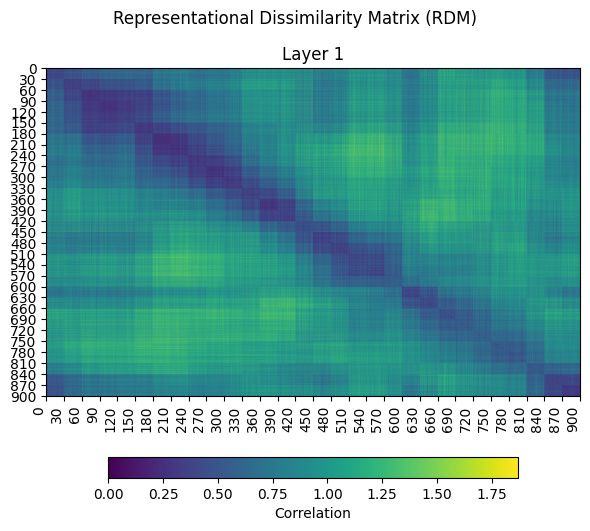

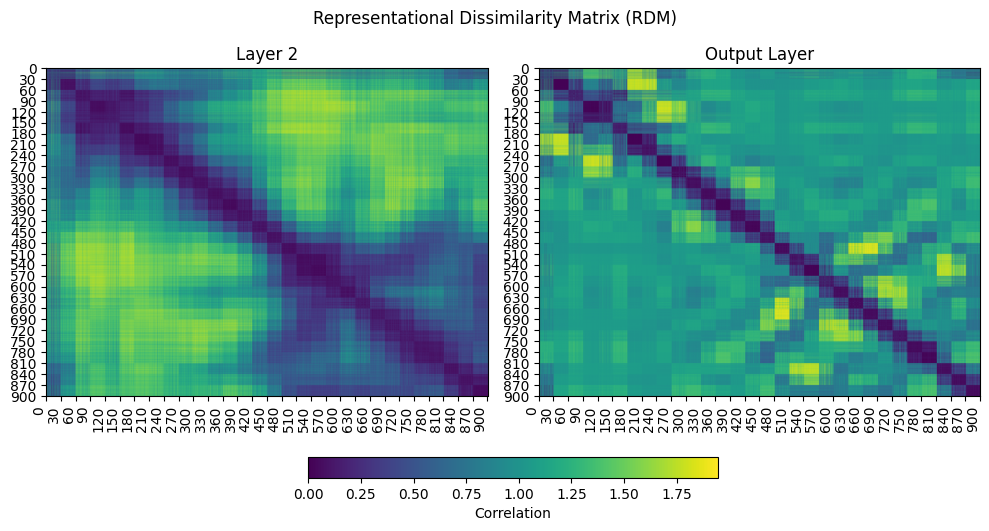

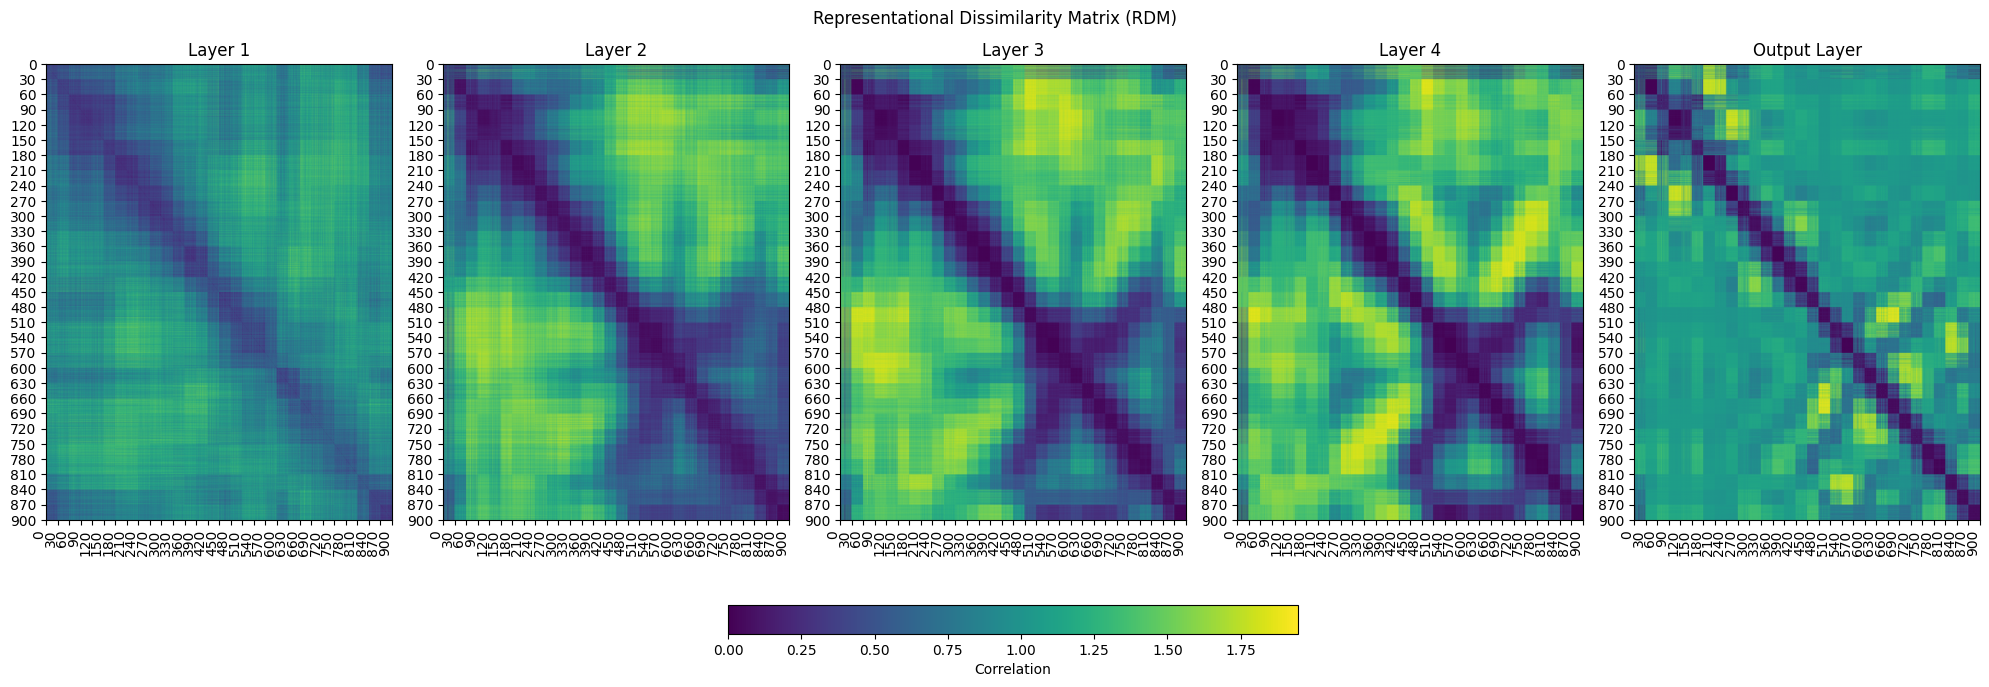

In [11]:
fig = rdm_single.plot(
        [multi_rdm_corr[0][0]],
        ["Layer 1"],
        metric="Correlation",
    )
fig2 = rdm_single.plot(
        [multi_rdm_corr[1][0], multi_rdm_corr[-1][0]],
        ["Layer 2", "Output Layer"],
        metric="Correlation",
    )
fig3 = rdm_single.plot(
        [
            multi_rdm_corr[0][0],
            multi_rdm_corr[1][0],
            multi_rdm_corr[2][0],
            multi_rdm_corr[3][0],
            multi_rdm_corr[-1][0],
        ],
        ["Layer 1", "Layer 2", "Layer 3", "Layer 4", "Output Layer"],
        metric="Correlation",
        figsize=(20, 8),
    )

We can compute the analysis on all instances and all models by passing the dictionary activations fully.

In [ ]:
rdm_dict = lens.compute_metric(activations_dict,
    lens.RDM(
        data=train_data,
        label=train_label,
        metric="correlation",
        bool_oracle=True,
        dataset_label=dataset_label,
    ))

In [ ]:
fig = lens.plot_rdm_correlation(rdm_dict)

### Distance metric analysis

A final embedding analysis can be done using cebra_lens: a distance analysis. They all utilise the binning as described in RDM (c.f. `cebra_lens.quantification.misc.discrete_binning()`).
Three distances can be computed:
- inter-bin -> between the bins (irrespective of repetitions)
- intra-bin -> inside of each bin
- inter-repetition -> distance between each repetition by computing centroid of each bin at each repetition

In [24]:
metric = "cosine"

#### Inter-repetition

In [ ]:
interrep_dict = lens.compute_metric(activations_dict,
    lens.Distance(
        data=train_data,
        label=train_label,
        dataset_label=dataset_label,
        metric=metric,
        distance_label="interrep",
    ))

Processing single_TR: 100%|██████████| 5/5 [00:00<00:00, 39.02it/s]


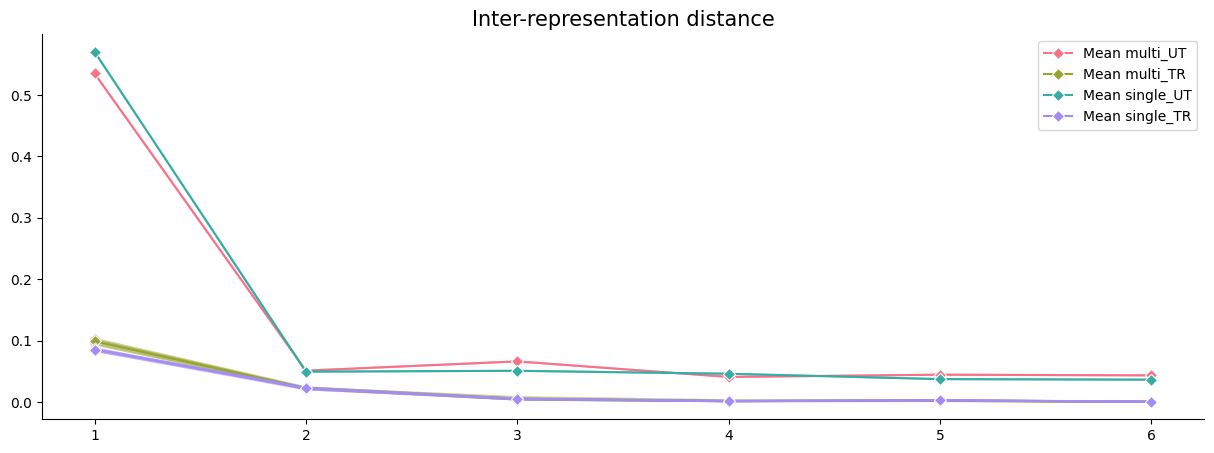

In [27]:
#figure out how to plot this
fig = lens.plot_distance(
    interrep_dict,
    title="Inter-representation distance",
)

#### Intra-bin

In [ ]:
intrabin_dict = lens.compute_metric(activations_dict,
    lens.Distance(
        data=train_data,
        label=train_label,
        dataset_label=dataset_label,
        metric=metric,
        distance_label="intrabin",
    ))

Processing single_TR: 100%|██████████| 5/5 [00:00<00:00, 13.02it/s]


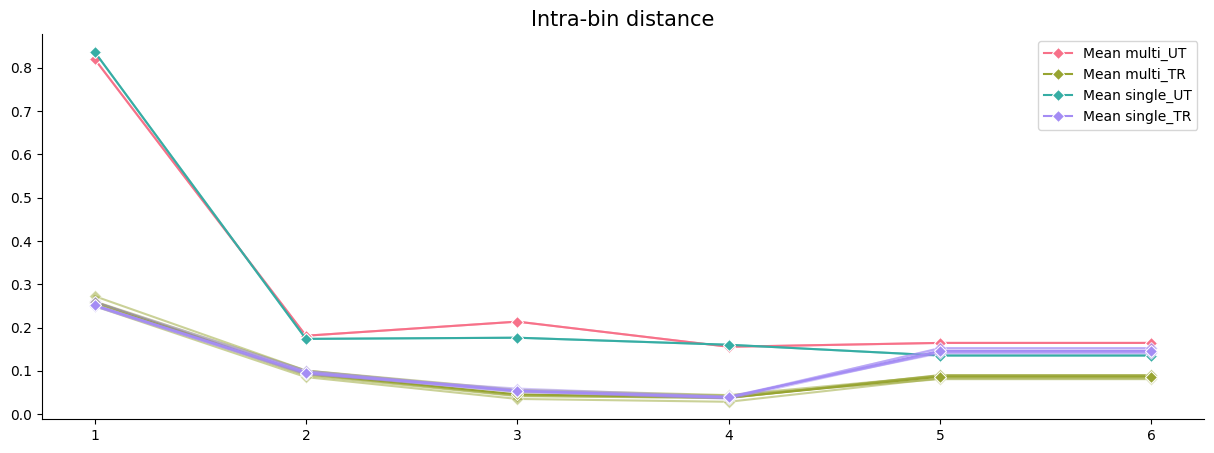

In [29]:
fig = lens.plot_distance(
    intrabin_dict,
    title="Intra-bin distance",
)

#### Inter-bin

In [ ]:
interbin_dict = lens.compute_metric(activations_dict,lens.Distance(
        data=train_data,
        label=train_label,
        dataset_label=dataset_label,
        metric=metric,
        distance_label="interbin",
    ))

Processing single_TR: 100%|██████████| 5/5 [00:00<00:00, 148.46it/s]


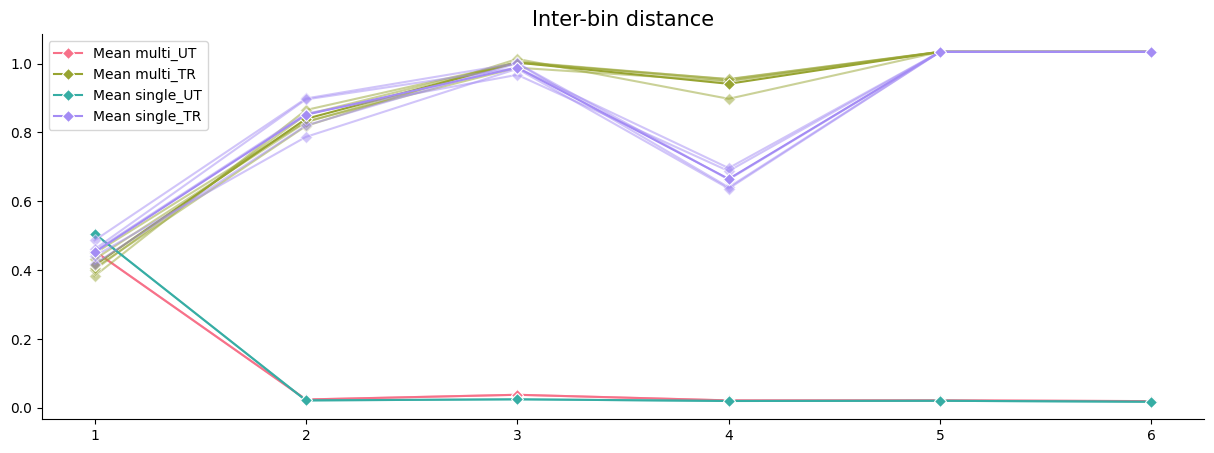

In [31]:
fig = lens.plot_distance(
    interbin_dict,
    title="Inter-bin distance",
)